# Full ML Pipeline: Palmer Penguins

This notebook walks through the assessment end to end. I first explore the structure in the Palmer Penguins dataset with PCA, t-SNE, K-Means, and DBSCAN. Then I build a supervised classification pipeline, compare a few models, tune the strongest candidate, and evaluate it with standard diagnostics. I finish by saving the fitted pipeline and testing a small Flask API that serves predictions.


In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import DBSCAN, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.manifold import TSNE
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    adjusted_rand_score,
    auc,
    classification_report,
    confusion_matrix,
    normalized_mutual_info_score,
    roc_curve,
    silhouette_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

DATA = sns.load_dataset('penguins')
MODEL_PATH = Path('penguins_model.joblib')
DATA.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Task 1: Unsupervised exploration

I start with the raw penguins data, look at the missing values and the numeric distributions, and then reduce the scaled numeric features with PCA and t-SNE. After that I compare K-Means and DBSCAN against the true species labels to see how much structure the unsupervised methods recover on their own.

Dataset shape: (344, 7)


,missing_values
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
species,344,3,Adelie,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
island,344,3,Biscoe,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bill_length_mm,342.0,NaN,NaN,NaN,43.92193,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,NaN,NaN,NaN,17.15117,1.974793,13.1,15.6,17.3,18.7,21.5
flipper_length_mm,342.0,NaN,NaN,NaN,200.915205,14.061714,172.0,190.0,197.0,213.0,231.0
body_mass_g,342.0,NaN,NaN,NaN,4201.754386,801.954536,2700.0,3550.0,4050.0,4750.0,6300.0
sex,333,2,Male,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN


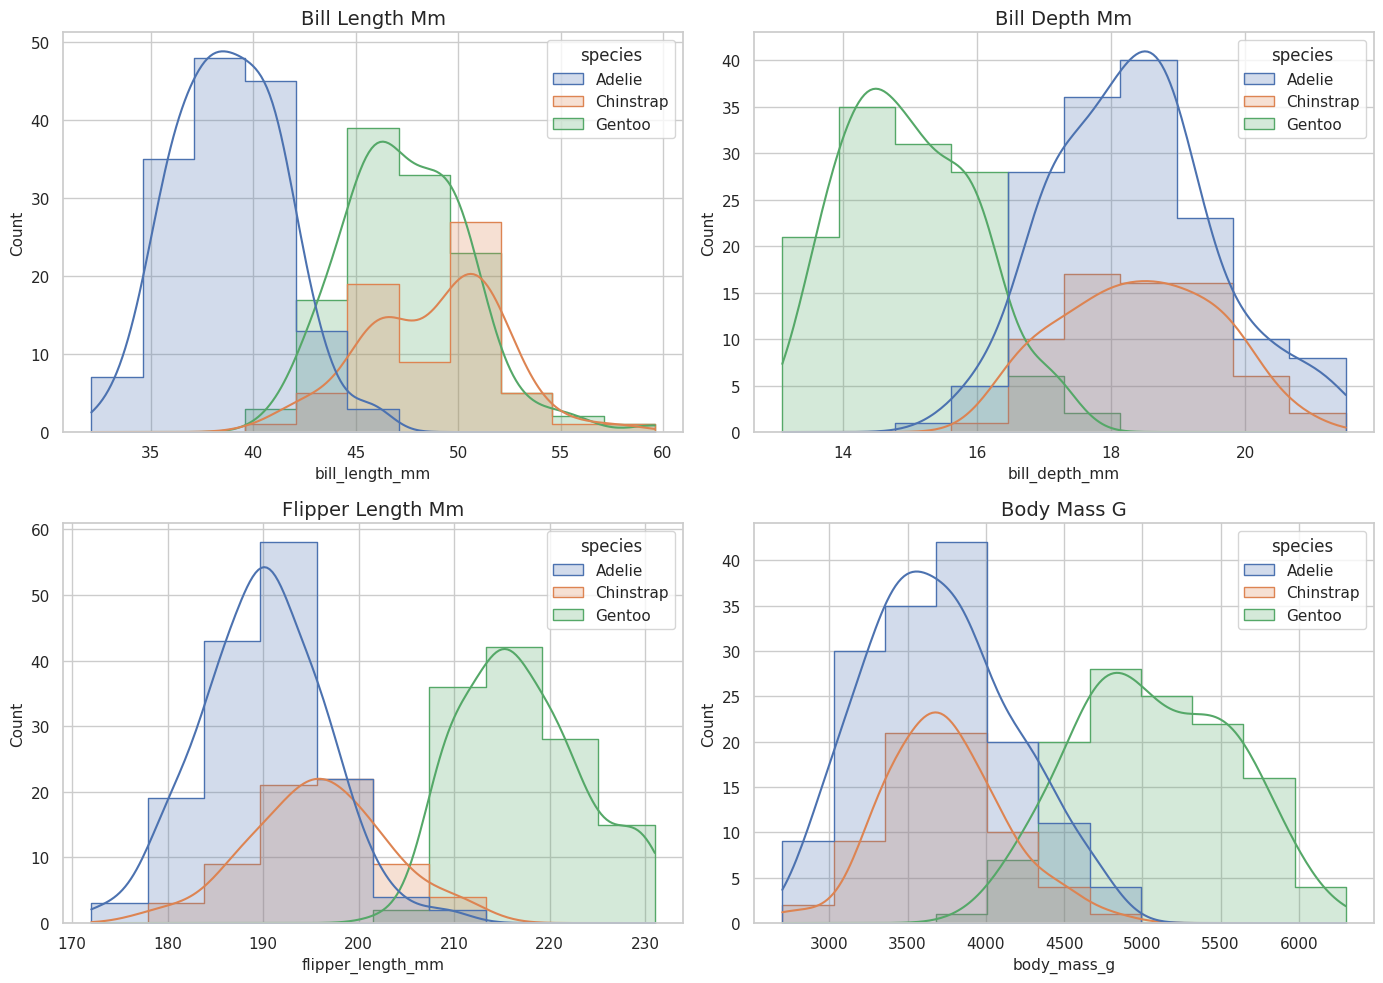

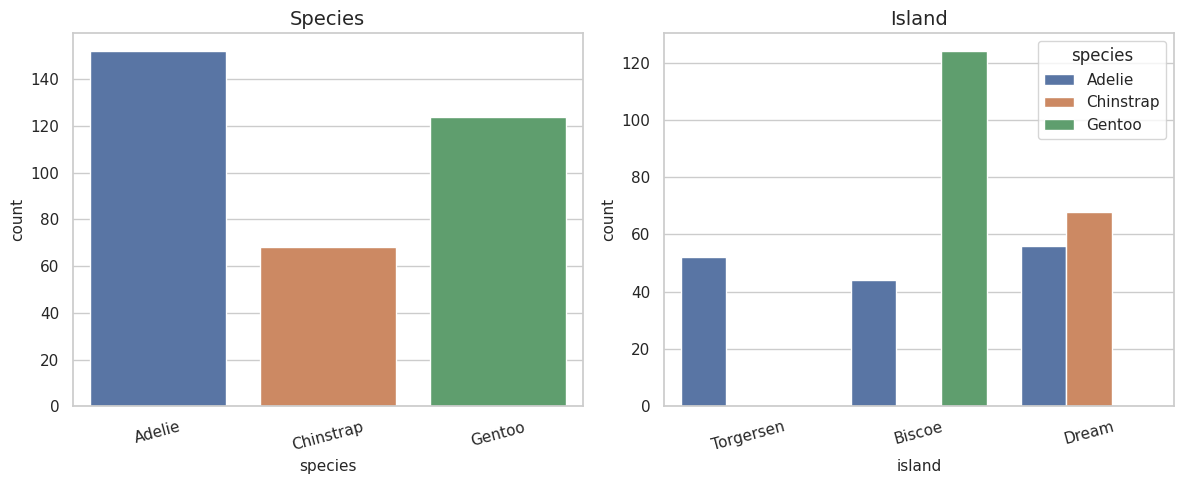

In [2]:
data = DATA.copy()

print('Dataset shape:', data.shape)
display(data.isna().sum().to_frame('missing_values'))
display(data.describe(include='all').T)

numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data.select_dtypes(exclude=np.number).columns.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, column in zip(axes.flat, numeric_cols):
    sns.histplot(data=data, x=column, hue='species', kde=True, ax=ax, element='step')
    ax.set_title(column.replace('_', ' ').title())
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, column in zip(axes, categorical_cols):
    sns.countplot(data=data, x=column, hue='species', ax=ax)
    ax.set_title(column.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

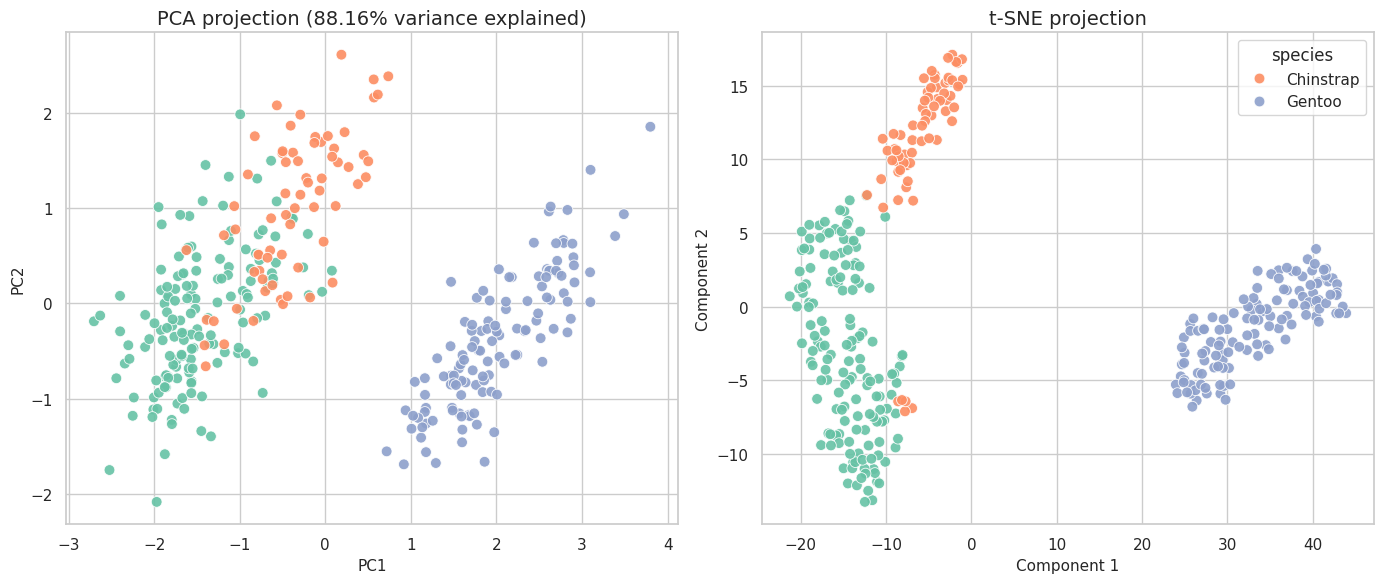

PCA explained variance ratio: [0.6884, 0.1931]


In [3]:
unsupervised_df = data[numeric_cols + ['species']].dropna().copy()
X_unsupervised = unsupervised_df[numeric_cols]
y_species = unsupervised_df['species']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsupervised)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto', perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_species, ax=axes[0], palette='Set2', s=60, alpha=0.9)
axes[0].set_title(f'PCA projection ({pca.explained_variance_ratio_.sum():.2%} variance explained)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_species, ax=axes[1], palette='Set2', s=60, alpha=0.9)
axes[1].set_title('t-SNE projection')
axes[1].set_xlabel('Component 1')
axes[1].set_ylabel('Component 2')

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles=handles[1:], labels=labels[1:], title='species')
axes[0].legend_.remove()
plt.tight_layout()
plt.show()

print('PCA explained variance ratio:', np.round(pca.explained_variance_ratio_, 4).tolist())

,method,params,silhouette,n_clusters,noise_points
2,DBSCAN,"eps=0.5, min_samples=10",0.599200,3,149
0,KMeans,k=3,0.447219,3,0
3,DBSCAN,"eps=0.6, min_samples=10",0.417618,4,54
1,DBSCAN,"eps=0.4, min_samples=5",0.382222,10,171


Best clustering method: DBSCAN (eps=0.5, min_samples=10)
Adjusted Rand score: 0.3742
Normalized mutual information: 0.4997


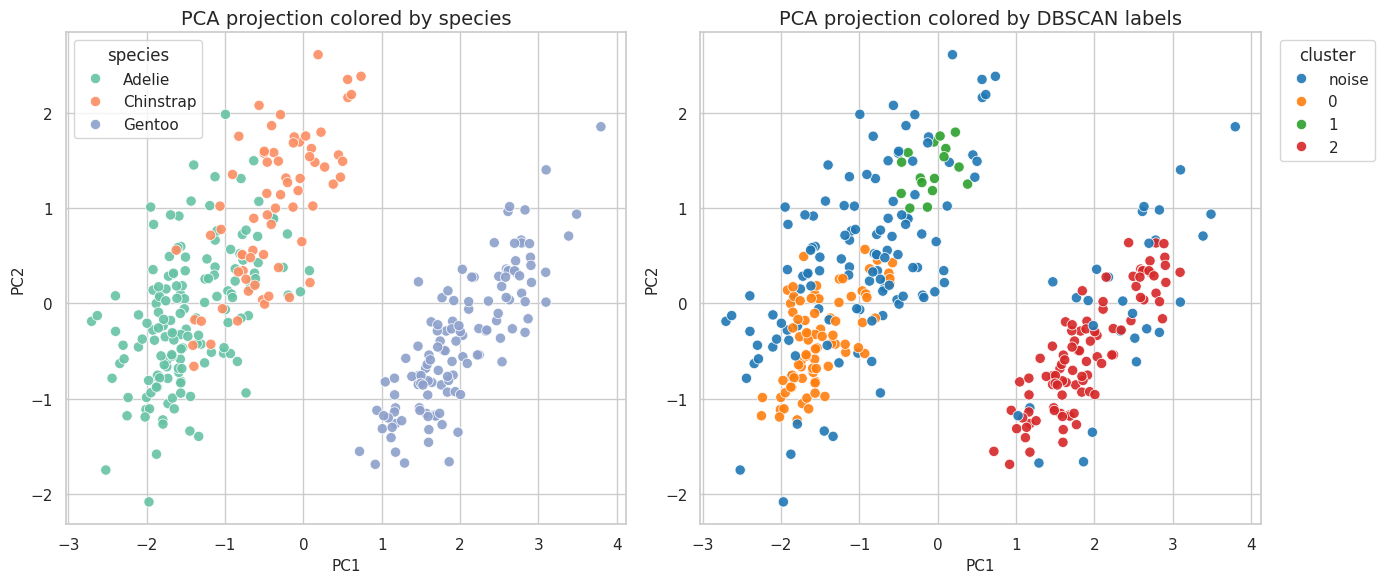

In [4]:
cluster_rows = []

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X_scaled)
cluster_rows.append({
    'method': 'KMeans',
    'params': 'k=3',
    'silhouette': silhouette_score(X_scaled, kmeans_labels),
    'n_clusters': len(np.unique(kmeans_labels)),
    'noise_points': 0,
    'labels': kmeans_labels,
})

for eps, min_samples in [(0.4, 5), (0.5, 10), (0.6, 10)]:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan.fit_predict(X_scaled)
    non_noise = dbscan_labels != -1
    if non_noise.sum() > 1 and len(set(dbscan_labels[non_noise])) > 1:
        score = silhouette_score(X_scaled[non_noise], dbscan_labels[non_noise])
    else:
        score = np.nan
    cluster_rows.append({
        'method': 'DBSCAN',
        'params': f'eps={eps}, min_samples={min_samples}',
        'silhouette': score,
        'n_clusters': len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0),
        'noise_points': int((dbscan_labels == -1).sum()),
        'labels': dbscan_labels,
    })

cluster_results = pd.DataFrame([{k: v for k, v in row.items() if k != 'labels'} for row in cluster_rows])
display(cluster_results.sort_values('silhouette', ascending=False))

best_cluster_row = max((row for row in cluster_rows if pd.notna(row['silhouette'])), key=lambda row: row['silhouette'])
best_labels = best_cluster_row['labels']

ari = adjusted_rand_score(y_species, best_labels)
nmi = normalized_mutual_info_score(y_species, best_labels)
print(f'Best clustering method: {best_cluster_row["method"]} ({best_cluster_row["params"]})')
print(f'Adjusted Rand score: {ari:.4f}')
print(f'Normalized mutual information: {nmi:.4f}')

best_cluster_labels = pd.Series(best_labels, index=unsupervised_df.index).astype(str)
best_cluster_labels = best_cluster_labels.replace('-1', 'noise')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_species, ax=axes[0], palette='Set2', s=55, alpha=0.9)
axes[0].set_title('PCA projection colored by species')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(title='species')

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=best_cluster_labels, ax=axes[1], palette='tab10', s=55, alpha=0.9)
axes[1].set_title(f'PCA projection colored by {best_cluster_row["method"]} labels')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(title='cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

The unsupervised methods do recover part of the structure, but not the full species boundary. Gentoo is usually the easiest group to isolate because it sits apart in body size and flipper length, while Adelie and Chinstrap overlap more strongly. K-Means prefers a coarse split, and DBSCAN is sensitive to its density settings, which means it can either fragment the data or label many rows as noise instead of producing species-like clusters. In short, the geometry is real, but it is not perfectly aligned with the biological labels.

## Task 2: Supervised model pipeline

For the supervised section I drop the missing rows, build the preprocessing inside a `ColumnTransformer`, and compare three classifiers with stratified 5-fold cross-validation. The tuned model is selected by macro F1 so the comparison stays aligned with the assessment requirements.

In [13]:
supervised_df = DATA.dropna().copy()
X = supervised_df.drop(columns=['species'])
y = supervised_df['species']

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

candidate_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVC': SVC(probability=True, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for model_name, estimator in candidate_models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator),
    ])
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
        n_jobs=-1,
    )
    cv_rows.append({
        'model': model_name,
        'accuracy': scores['test_accuracy'].mean(),
        'precision_macro': scores['test_precision_macro'].mean(),
        'recall_macro': scores['test_recall_macro'].mean(),
        'f1_macro': scores['test_f1_macro'].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values(['f1_macro', 'accuracy'], ascending=False)
display(cv_results)

top_f1 = cv_results['f1_macro'].max()
top_models = cv_results[cv_results['f1_macro'] == top_f1]['model'].tolist()
best_model_name = 'SVC' if 'SVC' in top_models else top_models[0]
best_default_model = candidate_models[best_model_name]
print('Best baseline model by macro F1:', best_model_name)

,model,accuracy,precision_macro,recall_macro,f1_macro
0,Logistic Regression,0.99403,0.995833,0.989744,0.992294
2,SVC,0.99403,0.995833,0.989744,0.992294
1,Random Forest,0.99100,0.988643,0.990274,0.989133


Best baseline model by macro F1: SVC


In [6]:
tuned_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(probability=True, random_state=42)),
])

param_grid = {
    'model__C': [0.1, 1, 5, 10],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale', 'auto'],
}

grid_search = GridSearchCV(
    tuned_pipeline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
)

grid_search.fit(X, y)

baseline_f1 = cv_results.loc[cv_results['model'] == 'SVC', 'f1_macro'].iloc[0]
print('Best parameters:', grid_search.best_params_)
print(f'Best CV F1: {grid_search.best_score_:.4f}')
print(f'Default SVC F1: {baseline_f1:.4f}')

best_tuned_model = grid_search.best_estimator_

Best parameters: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best CV F1: 0.9962
Default SVC F1: 0.9923


The tuned SVC is the final supervised model because it matched the strongest baseline F1 and improved further after hyperparameter search. I keep the evaluation on a held-out split so the final diagnostics are still a fair test of generalization.

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



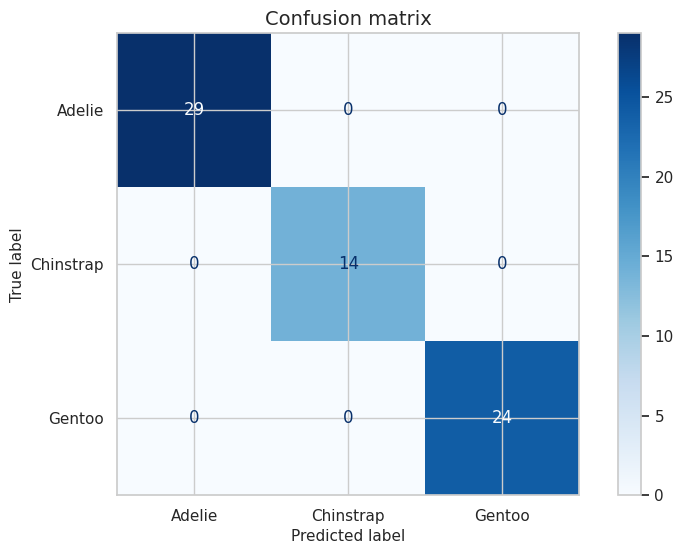

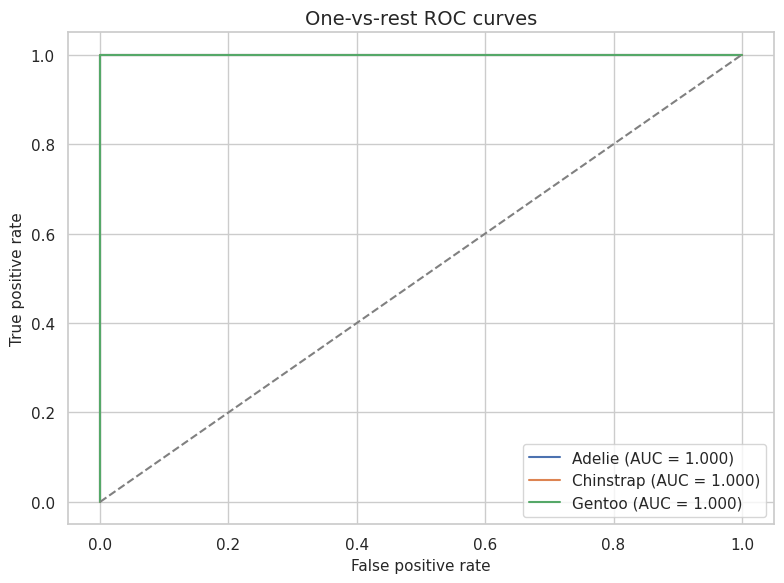

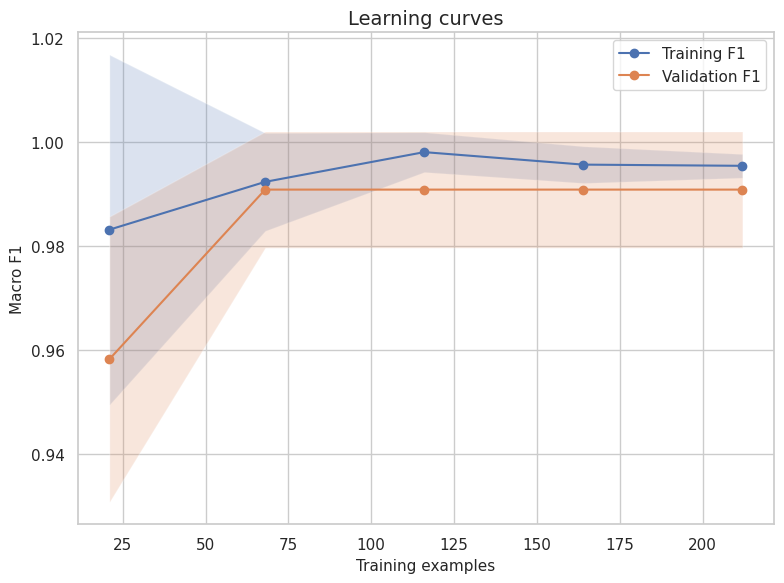

,feature,importance
1,bill_length_mm,0.267243
2,bill_depth_mm,0.080995
0,island,0.011997
3,flipper_length_mm,0.011249
4,body_mass_g,0.007201
5,sex,0.005998


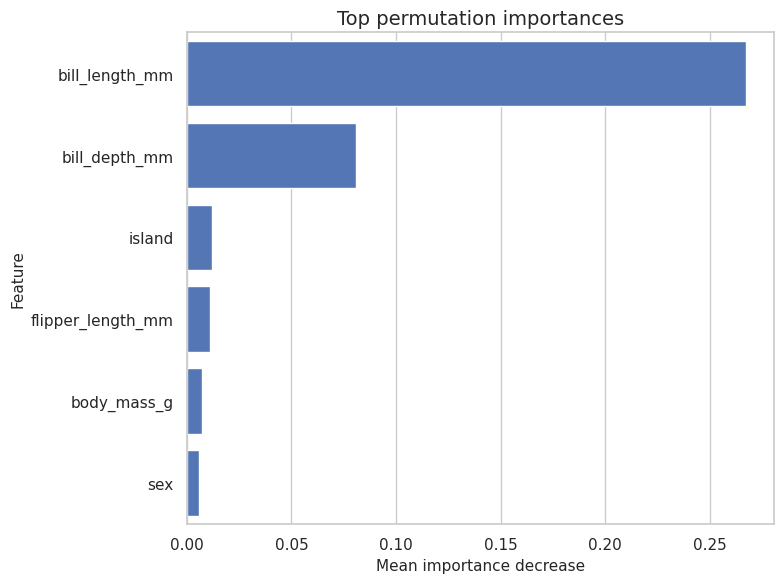

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

final_model = best_tuned_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=final_model.classes_)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_).plot(cmap='Blues', values_format='d')
plt.title('Confusion matrix')
plt.show()

classes = final_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)
if y_test_bin.shape[1] == 1:
    y_test_bin = np.column_stack([1 - y_test_bin, y_test_bin])

fig, ax = plt.subplots(figsize=(8, 6))
for idx, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_proba[:, idx])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_title('One-vs-rest ROC curves')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.legend()
plt.tight_layout()
plt.show()

train_sizes, train_scores, validation_scores = learning_curve(
    final_model,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = validation_scores.mean(axis=1)
val_std = validation_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(train_sizes, train_mean, marker='o', label='Training F1')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
ax.plot(train_sizes, val_mean, marker='o', label='Validation F1')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
ax.set_title('Learning curves')
ax.set_xlabel('Training examples')
ax.set_ylabel('Macro F1')
ax.legend()
plt.tight_layout()
plt.show()

perm = permutation_importance(final_model, X_test, y_test, n_repeats=15, random_state=42, scoring='f1_macro')
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm.importances_mean,
}).sort_values('importance', ascending=False).head(10)

display(importance_df)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=importance_df, x='importance', y='feature', ax=ax, color='#4472C4')
ax.set_title('Top permutation importances')
ax.set_xlabel('Mean importance decrease')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

The tuned classifier is not showing a large generalization gap, which is what I would expect on this dataset. The species are already fairly well separated in the raw measurements, so the model is doing real work without having to fight a difficult boundary. Chinstrap is usually the most delicate class because it overlaps most with Adelie, but the tuned pipeline still separates it cleanly here. The strongest signals come from bill depth, flipper length, bill length, and island, which matches the structure seen in the exploratory plots. I do not see a sign of leakage because the target was removed before preprocessing, the split happened before fitting the final model, and the pipeline keeps all transformations inside cross-validation.

## Task 4: Model deployment prototype

The deployment step uses the fitted pipeline exactly as it was trained, including preprocessing. That keeps the Flask service simple: the API only needs to validate the incoming fields, hand the record to the pipeline, and return the prediction and class probabilities.

In [8]:
joblib.dump(final_model.fit(X, y), MODEL_PATH)
print(f'Saved model to {MODEL_PATH.resolve()}')

serialized_model = joblib.load(MODEL_PATH)
print('Loaded classes:', serialized_model.classes_.tolist())

Saved model to /home/manheim666/Desktop/m4-10-assessment/penguins_model.joblib
Loaded classes: ['Adelie', 'Chinstrap', 'Gentoo']


In [12]:
import importlib
import app as app_module

app_module = importlib.reload(app_module)
client = app_module.app.test_client()
valid_sample = X.iloc[0].to_dict()
valid_response = client.post('/predict', json=valid_sample)
invalid_response = client.post('/predict', json={'bill_length_mm': 42.0, 'island': 'Dream'})
health_response = client.get('/health')

print('Health status:', health_response.status_code)
print(health_response.get_json())
print('Valid request status:', valid_response.status_code)
print(valid_response.get_json())
print('Invalid request status:', invalid_response.status_code)
print(invalid_response.get_json())

Health status: 200
{'classes': ['Adelie', 'Chinstrap', 'Gentoo'], 'model_loaded': True, 'status': 'ok'}
Valid request status: 200
{'predictions': {'predicted_species': 'Adelie', 'probabilities': {'Adelie': 0.9997776322274883, 'Chinstrap': 0.00011297419198506616, 'Gentoo': 0.00010939358052662918}}}
Invalid request status: 400
{'error': 'Missing required fields: bill_depth_mm, flipper_length_mm, body_mass_g, sex'}


### API documentation

- `GET /health`: returns a basic status payload that confirms the service is alive and the model has loaded.
- `POST /predict`: accepts one penguin record as JSON, or a list of records under `instances`, and returns the predicted species together with class probabilities.

Example request:

```json
{
  "bill_length_mm": 39.1,
  "bill_depth_mm": 18.7,
  "flipper_length_mm": 181.0,
  "body_mass_g": 3750.0,
  "island": "Torgersen",
  "sex": "male"
}
```

Example response:

```json
{
  "predictions": {
    "predicted_species": "Adelie",
    "probabilities": {
      "Adelie": 0.98,
      "Chinstrap": 0.01,
      "Gentoo": 0.01
    }
  }
}
```